We use this experiment to look at four questions from our group discussion. What changes when we rebalance at month-end instead of every four weeks? What happens if we short the lower-ranked stocks? How much do the factor portfolios overlap? And what changes when we remove sector differences from the signals?

We keep the same 20 US companies and saved Eulerpool data as the expanded experiment. We use Random Forest with fixed settings for the ML comparison. This lets us look at the portfolio rules without running another model competition. Each method has its own training targets because changing the factor portfolios also changes the returns we want to predict.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'inputs/us_stock_expanded').is_dir())
INPUTS = ROOT / 'inputs/us_stock_expanded'
RESULTS = ROOT / 'results/us_stock_monthly'
RESULTS.mkdir(parents=True, exist_ok=True)
companies = pd.read_csv(INPUTS / 'stocks.csv').set_index('ticker')
STOCKS = companies.index.tolist()
SECTORS = companies.sector
FACTORS = ['Value', 'Profitability', 'Momentum']
MODES = ['Long only', 'Long-short', 'Ranked long-short', 'Sector neutral']
FIRST_SIGNAL = pd.Timestamp('2023-01-31')
LAST_BOUNDARY = pd.Timestamp('2026-01-31')
PRICE_END = pd.Timestamp('2026-02-02')
INITIAL_VALUE = 100000.0
TRADING_COST = 0.001
BORROW_RATE = 0.03
pd.options.display.float_format = '{:,.3f}'.format
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False})

display(companies.groupby('sector').size().rename('Companies').to_frame())

,Companies
sector,
Consumer discretionary,3
Consumer staples,4
Energy,2
Health care,3
Industrials,2
Technology,4
Utilities,2


Our input files are in inputs/us_stock_expanded. We remove conflicting prices on the same date and keep only dates with prices for all 20 stocks. We do not fill missing prices. We end this comparison in early February 2026, before the larger gaps and the later Honeywell corporate action in the saved files.

Financial statements enter the calculations six months after their year-end and are used for at most 18 months after that year-end. These are the same rules as before. The provider's historical statements can include later revisions, and the companies were selected from stocks still trading today. Those properties of the data also apply here.

In [2]:
price_parts = []
price_checks = []
statements = {}
for stock in STOCKS:
    frame = pd.read_csv(INPUTS / f'{stock}_prices.csv', parse_dates=['date'])
    frame = frame.loc[(frame.date <= PRICE_END) & (frame.date.dt.dayofweek < 5)]
    if frame.close.isna().any() or frame.close.le(0).any() or not np.isfinite(frame.close).all():
        raise ValueError(f'Check prices for {stock}.')
    counts = frame.groupby('date').close.nunique()
    conflicts = counts.index[counts > 1]
    frame = frame.loc[~frame.date.isin(conflicts)].drop_duplicates('date')
    price_parts.append(frame.set_index('date').close.rename(stock))
    price_checks.append({'Stock': stock, 'Conflicting dates removed': len(conflicts)})
    income = pd.read_csv(INPUTS / f'{stock}_income.csv')
    actual = income.period.str.fullmatch(r'\d{4}-\d{2}-\d{2}')
    statement = income.loc[actual, ['period', 'netIncome', 'revenue', 'shares']].dropna().copy()
    statement['period'] = pd.to_datetime(statement.period)
    statement = statement.loc[(statement.shares > 0) & (statement.revenue > 0)].sort_values('period')
    if statement.period.duplicated().any():
        raise ValueError(f'Check statement dates for {stock}.')
    statement['available_date'] = statement.period + pd.DateOffset(months=6)
    statements[stock] = statement

all_prices = pd.concat(price_parts, axis=1).sort_index()
prices = all_prices.dropna()
weekly = prices.resample('W-FRI').last()
weekly_returns = weekly.pct_change(fill_method=None)
pd.DataFrame(price_checks).to_csv(RESULTS / 'price_checks.csv', index=False)
print(f'{len(prices):,} common price dates; {len(all_prices) - len(prices):,} incomplete dates removed.')
display(prices.iloc[[0, -1], :5])

2,995 common price dates; 44 incomplete dates removed.


C:\Users\Arian\AppData\Local\Temp\ipykernel_48028\4175158834.py:24: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  all_prices = pd.concat(price_parts, axis=1).sort_index()


,AAPL,MSFT,NVDA,ORCL,AMZN
date,,,,,
2014-01-02,19.750,37.160,0.396,37.840,19.898
2026-02-02,268.911,423.370,185.036,160.060,242.781


Value uses earnings yield, calculated from annual net income, the lagged annual share count and the last available price. Profitability uses net income divided by revenue. Momentum uses the return from 52 weeks ago to four weeks ago, divided by annualised weekly volatility. These practical measures are the same as in the earlier notebook.

The long-only factor portfolios hold the top five stocks equally. The first long-short version puts 50% in the top five and shorts 50% in the bottom five. We also include a ranked long-short version. Its weights follow each stock's distance from the average rank, so it uses the full group of stocks.

For the sector-neutral version, we take those same ranks and subtract the average rank within each sector. We then scale the weights so their absolute values sum to one. Each sector has equal long and short dollar exposure at the rebalance. Comparing this with the ranked long-short version isolates the sector adjustment. Sector neutrality here means zero net exposure in each sector at rebalance; it does not mean zero market beta. The group has only two to four companies in each sector.

In [3]:
def next_close(signal):
    position = prices.index.searchsorted(signal, side='right')
    if position >= len(prices) or (prices.index[position] - signal).days > 7:
        raise ValueError(f'No nearby execution price for {signal.date()}.')
    return prices.index[position]

def scores_at(signal):
    history = weekly.loc[:signal].tail(53)
    if len(history) != 53 or history.isna().any().any():
        raise ValueError(f'Incomplete weekly history for {signal.date()}.')
    vol = history.pct_change(fill_method=None).iloc[1:].std() * np.sqrt(52)
    momentum = (history.iloc[-5] / history.iloc[0] - 1) / vol
    close = prices.loc[:signal].iloc[-1]
    scores = pd.DataFrame(index=STOCKS, columns=FACTORS, dtype=float)
    for stock in STOCKS:
        available = statements[stock].loc[statements[stock].available_date <= signal]
        if available.empty:
            raise ValueError(f'No available statement for {stock}.')
        row = available.iloc[-1]
        if signal > row.period + pd.DateOffset(months=18):
            raise ValueError(f'The statement for {stock} is too old.')
        scores.loc[stock] = [row.netIncome / (close[stock] * row.shares), row.netIncome / row.revenue, momentum[stock]]
    if not np.isfinite(scores.to_numpy()).all():
        raise ValueError('The factor scores must be finite.')
    return scores

def make_buckets(scores, mode):
    weights = pd.DataFrame(0.0, index=STOCKS, columns=FACTORS)
    for factor in FACTORS:
        ranked = scores[factor].sort_values(ascending=False, kind='stable').index
        if mode == 'Long only':
            weights.loc[ranked[:5], factor] = 0.2
        elif mode == 'Long-short':
            weights.loc[ranked[:5], factor] = 0.1
            weights.loc[ranked[-5:], factor] = -0.1
        else:
            ranks = scores[factor].rank(method='average')
            center = ranks.groupby(SECTORS).transform('mean') if mode == 'Sector neutral' else ranks.mean()
            signal = ranks - center
            weights[factor] = signal / signal.abs().sum()
    return weights

def model_inputs(signal, buckets):
    history = weekly.loc[:signal]
    past = weekly_returns.loc[:signal].tail(13).dot(buckets)
    values = {}
    for factor in FACTORS:
        for weeks in [1, 4, 13]:
            values[f'{factor}_{weeks}w'] = (history.iloc[-1] / history.iloc[-1-weeks] - 1).dot(buckets[factor])
        values[f'{factor}_volatility'] = past[factor].std() * np.sqrt(52)
    values['factor_correlation'] = past.corr().to_numpy()[np.triu_indices(3, 1)].mean()
    return values

The monthly comparison starts with the 31 January 2023 signal. Trades use the next common observed closing price, on 1 February. It ends on 2 February 2026, after 36 completed monthly holding periods. The four-week reference starts with the same signal and holdings, then uses 28-day intervals. Its final position is valued on the same ending date, even though that last four-week interval is shorter.

All signals use information available by their date. The return and volatility inputs use completed weekly observations. Monthly models are trained on earlier month-end observations, using one set of 13 inputs per month. This is a smaller input setup than the eight-week sequences in the previous notebook. Every portfolio construction in this notebook uses this same setup.

In [4]:
month_ends = pd.date_range('2016-10-31', LAST_BOUNDARY, freq='ME')
test_signals = month_ends[(month_ends >= FIRST_SIGNAL) & (month_ends < LAST_BOUNDARY)]
monthly_schedule = pd.DataFrame({
    'signal': test_signals,
    'entry': [next_close(d) for d in test_signals],
    'exit': [next_close(d + pd.offsets.MonthEnd(1)) for d in test_signals]
})
four_week_signals = pd.date_range(FIRST_SIGNAL, LAST_BOUNDARY, freq='28D')
four_week_entries = [next_close(d) for d in four_week_signals]
four_week_schedule = pd.DataFrame({
    'signal': four_week_signals,
    'entry': four_week_entries,
    'exit': four_week_entries[1:] + [monthly_schedule.exit.iloc[-1]]
})
score_history = {d: scores_at(d) for d in month_ends.union(four_week_signals)}
buckets = {(mode, d): make_buckets(score_history[d], mode) for mode in MODES for d in month_ends}
inputs = {}
targets = {}
label_end = pd.Series(pd.NaT, index=month_ends, dtype='datetime64[ns]')
for mode in MODES:
    inputs[mode] = pd.DataFrame([model_inputs(d, buckets[(mode, d)]) for d in month_ends], index=month_ends)
    targets[mode] = pd.DataFrame(index=month_ends, columns=FACTORS, dtype=float)
    for signal, following in zip(month_ends[:-1], month_ends[1:]):
        entry, exit_date = next_close(signal), next_close(following)
        targets[mode].loc[signal] = (prices.loc[exit_date] / prices.loc[entry] - 1).dot(buckets[(mode, signal)])
        label_end.loc[signal] = exit_date

monthly_schedule.to_csv(RESULTS / 'monthly_schedule.csv', index=False)
four_week_schedule.to_csv(RESULTS / 'four_week_schedule.csv', index=False)
pd.concat(score_history, names=['signal', 'stock']).to_csv(RESULTS / 'factor_scores.csv')
print(f'{len(test_signals)} monthly periods and {len(four_week_signals)} four-week positions.')
display(monthly_schedule.iloc[[0, -1]])

36 monthly periods and 40 four-week positions.


,signal,entry,exit
0,2023-01-31,2023-02-01,2023-03-01
35,2025-12-31,2026-01-05,2026-02-02


Random Forest predicts the next month's gross return for each factor portfolio. We refit it at every monthly signal and only use training outcomes that ended before that signal. It has 150 trees, a maximum depth of four and at least 12 training rows in each leaf. These settings stay fixed.

The factor with the highest forecast receives 50%, the middle one receives 30% and the lowest receives 20%. Equal factor weights give us a comparison for each construction. We rebuild the training inputs and returns for each construction, so a long-short portfolio is predicted from its own history. The test period has already been explored in our earlier work; this is a follow-up research comparison.

In [5]:
forecast_rows = []
training_rows = []
factor_allocations = {}
for mode in MODES:
    for signal in test_signals:
        eligible = label_end.lt(signal) & targets[mode].notna().all(axis=1)
        train_x = inputs[mode].loc[eligible]
        train_y = targets[mode].loc[eligible]
        if len(train_x) < 60:
            raise ValueError('At least 60 completed monthly observations are required.')
        model = RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12, random_state=42, n_jobs=2)
        model.fit(train_x, train_y)
        predicted = pd.Series(model.predict(inputs[mode].loc[[signal]])[0], index=FACTORS)
        ranking = predicted.sort_values(ascending=False, kind='stable').index
        factor_allocations[(mode, signal)] = pd.Series([0.5, 0.3, 0.2], index=ranking).reindex(FACTORS)
        training_rows.append({'mode': mode, 'signal': signal, 'training_months': len(train_x), 'latest_training_exit': label_end.loc[eligible].max()})
        for factor in FACTORS:
            forecast_rows.append({'mode': mode, 'signal': signal, 'factor': factor, 'prediction': predicted[factor], 'actual': targets[mode].loc[signal, factor], 'training_mean': train_y[factor].mean()})
    print(f'Finished {mode}.')

forecasts = pd.DataFrame(forecast_rows)
forecasts.to_csv(RESULTS / 'predictions.csv', index=False)
pd.DataFrame(training_rows).to_csv(RESULTS / 'training_dates.csv', index=False)
pd.concat(inputs, names=['mode', 'signal']).to_csv(RESULTS / 'model_inputs.csv')
pd.concat(targets, names=['mode', 'signal']).to_csv(RESULTS / 'model_targets.csv')

Finished Long only.


Finished Long-short.


Finished Ranked long-short.


Finished Sector neutral.


When the same stock appears in several factors, we add its positions together before calculating trades. A long position in one factor can offset a short position in another. We keep that offset instead of increasing the positions again. This can leave the combined portfolio with less than 100% gross stock exposure.

For the long-only version, shared stocks can receive a higher total weight. We measure the overlap and the final stock and sector weights below. We do not remove a company just because it scores well on more than one factor.

In [6]:
weights = {}
schedules = {}
construction = {}
factor_rows = []
weights['Four-week equal factors'] = pd.DataFrame({d: make_buckets(score_history[d], 'Long only').mean(axis=1) for d in four_week_signals}).T
schedules['Four-week equal factors'] = four_week_schedule
construction['Four-week equal factors'] = 'Long only'
weights['Monthly equal stocks'] = pd.DataFrame(1 / len(STOCKS), index=test_signals, columns=STOCKS)
schedules['Monthly equal stocks'] = monthly_schedule
construction['Monthly equal stocks'] = 'Long only'
for mode in MODES:
    for allocation in ['Equal factors', 'Random Forest']:
        name = f'{mode} | {allocation}'
        rows = {}
        for signal in test_signals:
            factor_weight = pd.Series(1 / 3, index=FACTORS) if allocation == 'Equal factors' else factor_allocations[(mode, signal)]
            rows[signal] = buckets[(mode, signal)].dot(factor_weight)
            factor_rows.append({'strategy': name, 'signal': signal, **factor_weight.to_dict()})
        weights[name] = pd.DataFrame(rows).T
        schedules[name] = monthly_schedule
        construction[name] = mode

pd.concat(weights, names=['strategy', 'signal']).to_csv(RESULTS / 'stock_weights.csv')
pd.DataFrame(factor_rows).to_csv(RESULTS / 'factor_weights.csv', index=False)
pd.concat(buckets, names=['mode', 'signal', 'stock']).to_csv(RESULTS / 'bucket_weights.csv')
display(pd.DataFrame({mode: weights[f'{mode} | Random Forest'].iloc[-1] * 100 for mode in MODES}).join(SECTORS).round(2))

,Long only,Long-short,Ranked long-short,Sector neutral,sector
AAPL,0.000,-2.000,0.700,-1.760,Technology
MSFT,10.000,3.000,4.300,2.830,Technology
NVDA,10.000,1.000,3.900,1.640,Technology
ORCL,0.000,-2.000,-0.400,-2.700,Technology
AMZN,0.000,-3.000,-5.000,-3.470,Consumer discretionary
HD,0.000,-8.000,-5.000,-3.070,Consumer discretionary
MCD,10.000,3.000,4.100,6.540,Consumer discretionary
WMT,6.000,0.000,-4.400,-0.170,Consumer staples
COST,0.000,-10.000,-7.900,-7.340,Consumer staples
PG,0.000,-5.000,-1.200,-0.410,Consumer staples


Every strategy starts with USD 100,000. Trading costs are 0.10% of each amount bought or sold, including opening positions. We assume a 3% annual borrowing cost on the value of short positions, charged over the calendar days they are held. We also show 0% and 6% borrowing assumptions later. These are research assumptions, not observed borrowing quotes.

Each long-short factor starts with 50% long and 50% short exposure. Its combined portfolio keeps cash and signed stock positions, so short-sale proceeds are not counted as profit. Cash earns no interest. We do not model margin calls, changing stock availability, recalls, taxes or market impact. Dividend treatment in the saved prices has not been verified, and we do not separately add dividends or short-dividend payments. Results are therefore price-based simulations with the stated cost assumptions.

The same shares are held between rebalances. We charge borrowing on the previous observed short position value for the elapsed calendar days. Remaining positions are valued at the end without a final sale.

In [7]:
def backtest(prices, schedule, targets, initial_value=100000.0, trading_cost=0.001, borrow_rate=0.03):
    prices = prices.copy()
    schedule = schedule[['signal', 'entry', 'exit']].copy()
    targets = targets.copy()
    prices.index = pd.to_datetime(prices.index)
    targets.index = pd.to_datetime(targets.index)
    for column in schedule:
        schedule[column] = pd.to_datetime(schedule[column])
    settings = np.asarray([initial_value, trading_cost, borrow_rate], dtype=float)
    if not np.isfinite(settings).all() or initial_value <= 0 or trading_cost < 0 or borrow_rate < 0:
        raise ValueError('Check the starting value and cost assumptions.')
    if prices.empty or schedule.empty or prices.index.has_duplicates or not prices.index.is_monotonic_increasing:
        raise ValueError('Prices and holding dates must be present and in date order.')
    if prices.columns.has_duplicates or targets.index.has_duplicates or targets.columns.has_duplicates:
        raise ValueError('Stock names and target dates must be unique.')
    if not np.isfinite(prices.to_numpy(dtype=float)).all() or prices.le(0).any().any():
        raise ValueError('Prices must be positive and complete.')
    if set(targets.columns) != set(prices.columns):
        raise ValueError('Prices and targets must contain the same stocks.')
    if schedule.isna().any().any() or schedule.signal.duplicated().any() or not schedule.signal.is_monotonic_increasing:
        raise ValueError('Signal dates must be complete, unique and in date order.')
    if not ((schedule.signal < schedule.entry) & (schedule.entry < schedule.exit)).all():
        raise ValueError('Each signal must precede its entry and exit.')
    if not schedule.entry.isin(prices.index).all() or not schedule.exit.isin(prices.index).all():
        raise ValueError('Every entry and exit must have an observed price.')
    if len(schedule) > 1 and not np.array_equal(schedule.exit.iloc[:-1].to_numpy(), schedule.entry.iloc[1:].to_numpy()):
        raise ValueError('Holding periods must connect at the next rebalance.')
    targets = targets.reindex(index=schedule.signal, columns=prices.columns).astype(float)
    if not np.isfinite(targets.to_numpy()).all():
        raise ValueError('Every signal must have complete target weights.')
    if (trading_cost * targets.abs().sum(axis=1) >= 1).any():
        raise ValueError('Target exposure is too large for the trading cost assumption.')
    cash = float(initial_value)
    shares = pd.Series(0.0, index=prices.columns)
    nav_parts = [pd.Series([initial_value], index=[schedule.signal.iloc[0]])]
    exposure_parts = [pd.DataFrame({'signal': [schedule.signal.iloc[0]], 'long': [0.0], 'short': [0.0], 'gross': [0.0], 'net': [0.0], 'cash': [1.0], 'largest_position': [0.0]}, index=[schedule.signal.iloc[0]])]
    trades = []
    for row in schedule.itertuples(index=False):
        current = shares * prices.loc[row.entry]
        wealth = float(cash + current.sum())
        target = targets.loc[row.signal]
        if wealth <= 0 or trading_cost * current.abs().sum() >= wealth:
            raise ValueError('The portfolio cannot cover its trading costs.')
        lower, upper = 0.0, wealth
        for step in range(60):
            middle = (lower + upper) / 2
            required = middle + trading_cost * (target * middle - current).abs().sum()
            if required > wealth:
                upper = middle
            else:
                lower = middle
        after_cost = (lower + upper) / 2
        traded_value = float((target * after_cost - current).abs().sum())
        shares = target * after_cost / prices.loc[row.entry]
        cash = float(after_cost - (shares * prices.loc[row.entry]).sum())
        holdings = prices.loc[row.entry:row.exit].mul(shares, axis=1)
        days = holdings.index.to_series().diff().dt.total_seconds().fillna(0) / 86400
        short_value = -holdings.clip(upper=0).sum(axis=1)
        borrowing = short_value.shift(1, fill_value=0) * borrow_rate * days / 365.25
        cash_path = cash - borrowing.cumsum()
        nav = holdings.sum(axis=1) + cash_path
        if not np.isfinite(nav.to_numpy()).all() or nav.le(0).any():
            raise ValueError('The portfolio value became nonpositive or invalid.')
        long_value = holdings.clip(lower=0).sum(axis=1)
        exposure = pd.DataFrame({'signal': row.signal, 'long': long_value / nav, 'short': short_value / nav, 'gross': (long_value + short_value) / nav, 'net': holdings.sum(axis=1) / nav, 'cash': cash_path / nav, 'largest_position': holdings.abs().max(axis=1) / nav})
        nav_parts.append(nav)
        exposure_parts.append(exposure)
        trades.append({'signal': row.signal, 'entry': row.entry, 'exit': row.exit, 'turnover_fraction': traded_value / wealth, 'traded_value_usd': traded_value, 'pre_trade_value_usd': wealth, 'post_trade_value_usd': after_cost, 'cost_usd': wealth - after_cost, 'borrow_usd': float(borrowing.sum())})
        cash = float(cash_path.iloc[-1])
    nav = pd.concat(nav_parts)
    nav = nav.loc[~nav.index.duplicated(keep='last')].sort_index().rename('portfolio_value')
    exposure = pd.concat(exposure_parts)
    exposure = exposure.loc[~exposure.index.duplicated(keep='last')].sort_index()
    nav.index.name = 'date'
    exposure.index.name = 'date'
    return nav, pd.DataFrame(trades), exposure

In [8]:
nav_series = []
trade_parts = []
daily_parts = []
for name, target in weights.items():
    nav, trade_log, daily_log = backtest(prices, schedules[name], target, INITIAL_VALUE, TRADING_COST, BORROW_RATE)
    nav_series.append(nav.rename(name))
    trade_parts.append(trade_log.assign(strategy=name))
    daily_parts.append(daily_log.reset_index().assign(strategy=name))
portfolio_values = pd.concat(nav_series, axis=1)
trades = pd.concat(trade_parts, ignore_index=True)
daily_exposure = pd.concat(daily_parts, ignore_index=True)
portfolio_values.to_csv(RESULTS / 'portfolio_values.csv', index_label='date')
trades.to_csv(RESULTS / 'trading_costs.csv', index=False)
daily_exposure.to_csv(RESULTS / 'daily_exposure.csv', index=False)

def performance_row(nav, log):
    years = (nav.index[-1] - nav.index[0]).days / 365.25
    weekly_nav = nav.resample('W-FRI').last()
    weekly_nav = weekly_nav.loc[weekly_nav.index <= nav.index[-1]]
    returns = weekly_nav.pct_change(fill_method=None).dropna()
    volatility = returns.std() * np.sqrt(52)
    return {
        'Annual return %': 100 * ((nav.iloc[-1] / INITIAL_VALUE) ** (1 / years) - 1),
        'Volatility %': 100 * volatility,
        'Sharpe (0% reference)': returns.mean() / returns.std() * np.sqrt(52),
        'Max drawdown %': 100 * (nav / nav.cummax() - 1).min(),
        'Final value USD': nav.iloc[-1],
        'Annual traded notional %': 100 * log.turnover_fraction.sum() / years,
        'Trading costs USD': log.cost_usd.sum(),
        'Borrowing costs USD': log.borrow_usd.sum(),
        'Rebalances': len(log)
    }

performance = pd.DataFrame({name: performance_row(portfolio_values[name], trades.loc[trades.strategy == name]) for name in weights}).T
performance.index.name = 'Strategy'
performance.to_csv(RESULTS / 'performance.csv')
display(performance.round(2))

,Annual return %,Volatility %,Sharpe (0% reference),Max drawdown %,Final value USD,Annual traded notional %,Trading costs USD,Borrowing costs USD,Rebalances
Strategy,,,,,,,,,
Four-week equal factors,16.850,12.230,1.340,-17.820,"159,679.710",327.430,"1,209.030",0.000,40.000
Monthly equal stocks,17.630,10.500,1.590,-15.680,"162,926.270",87.440,308.160,0.000,36.000
Long only | Equal factors,17.120,12.070,1.370,-16.920,"160,807.280",312.030,"1,157.300",0.000,36.000
Long only | Random Forest,15.820,13.090,1.200,-18.830,"155,509.050",484.380,"1,795.660",0.000,36.000
Long-short | Equal factors,-2.260,4.170,-0.480,-11.300,"93,346.850",288.760,817.180,"2,414.030",36.000
Long-short | Random Forest,-2.510,5.220,-0.400,-11.010,"92,648.790",504.840,"1,439.230","2,769.070",36.000
Ranked long-short | Equal factors,-1.960,3.330,-0.520,-9.130,"94,228.470",217.210,620.260,"1,940.840",36.000
Ranked long-short | Random Forest,-1.400,4.410,-0.220,-5.850,"95,853.590",352.400,"1,033.430","2,257.710",36.000
Sector neutral | Equal factors,-3.160,3.020,-1.060,-12.680,"90,809.880",247.410,697.070,"2,066.490",36.000


The tables use the same starting capital and comparison dates. Long-only portfolios start fully invested in stocks. Long-short portfolios have zero net stock exposure and may have lower gross exposure after positions cancel. Their returns therefore represent different exposures. We show both return and risk measures rather than treating the largest return as the answer to every question.

Annual traded notional counts purchases and sales together, including the initial positions. Volatility and Sharpe ratios use weekly portfolio changes and 52 weeks per year. Drawdown uses the available daily values. The 3% borrowing assumption applies only to short positions.

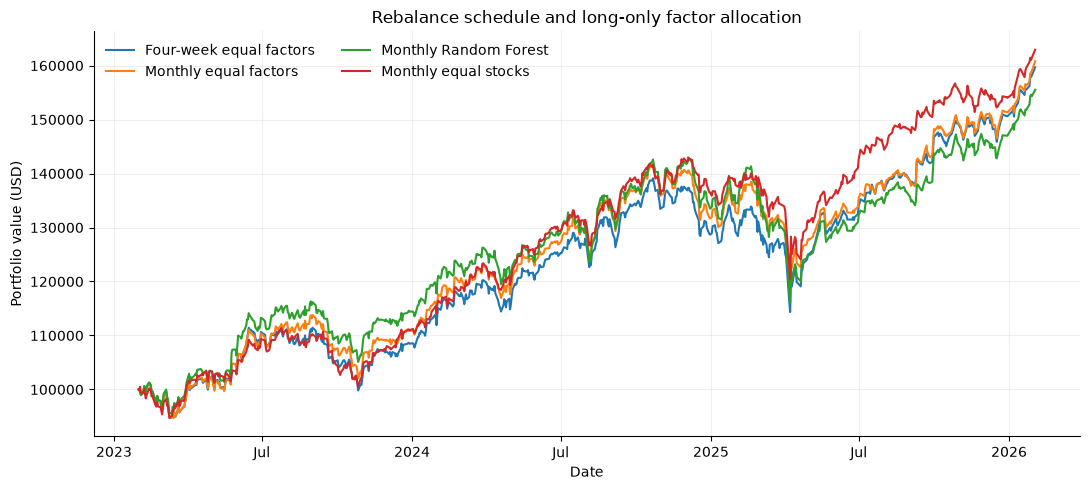

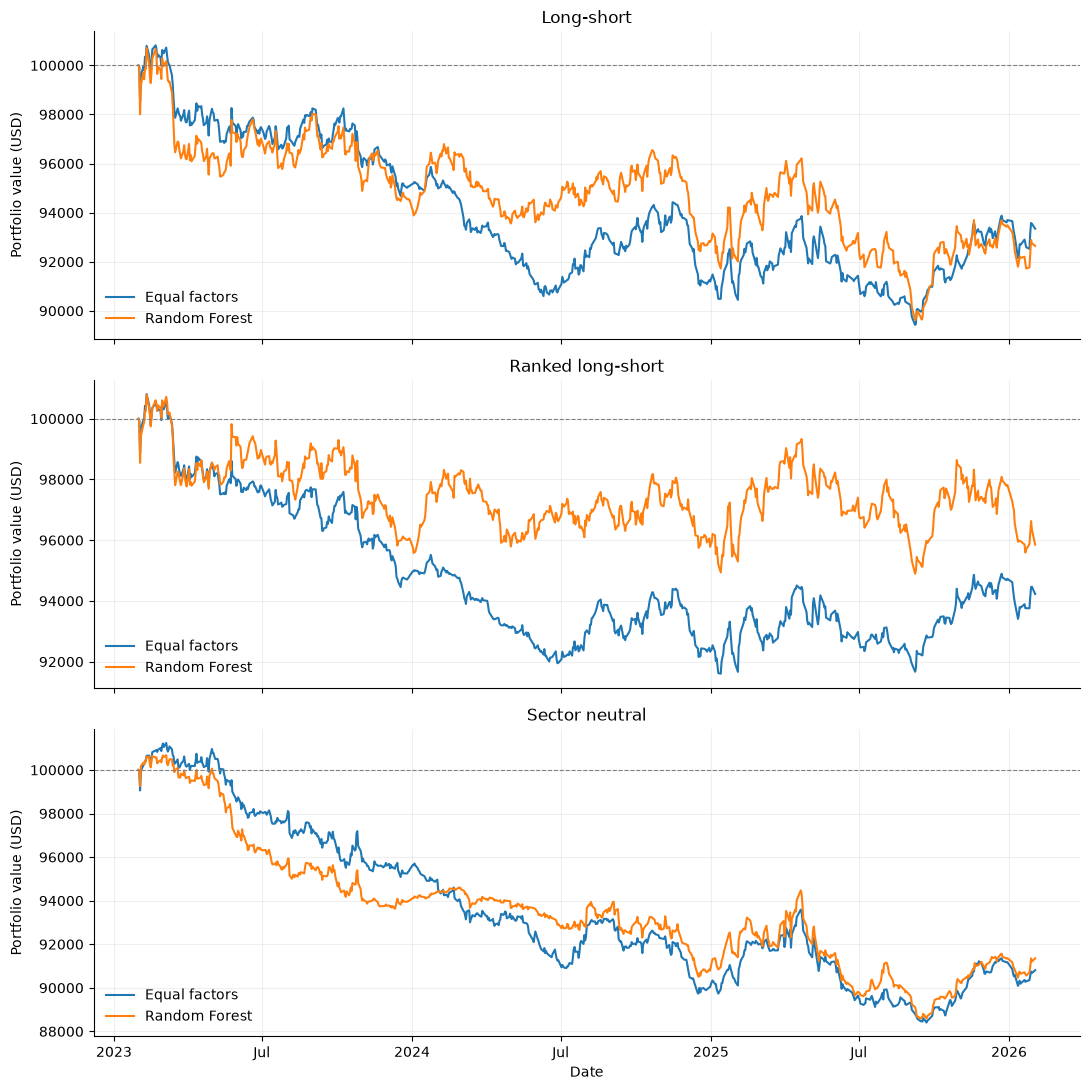

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
for name in ['Four-week equal factors', 'Long only | Equal factors', 'Long only | Random Forest', 'Monthly equal stocks']:
    label = 'Monthly equal factors' if name == 'Long only | Equal factors' else name.replace('Long only | ', 'Monthly ')
    ax.plot(portfolio_values.index, portfolio_values[name], label=label)
ax.set(title='Rebalance schedule and long-only factor allocation', ylabel='Portfolio value (USD)', xlabel='Date')
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)
locator = AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
fig.tight_layout()
fig.savefig(RESULTS / 'schedule_comparison.png', dpi=160)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
for ax, mode in zip(axes, MODES[1:]):
    for allocation in ['Equal factors', 'Random Forest']:
        ax.plot(portfolio_values.index, portfolio_values[f'{mode} | {allocation}'], label=allocation)
    ax.axhline(INITIAL_VALUE, color='gray', linewidth=0.8, linestyle='--')
    ax.set(title=mode, ylabel='Portfolio value (USD)')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
locator = AutoDateLocator(minticks=5, maxticks=8)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(ConciseDateFormatter(locator))
axes[-1].set_xlabel('Date')
fig.tight_layout()
fig.savefig(RESULTS / 'long_short_comparison.png', dpi=160)
plt.show()

In [10]:
overlap_rows = []
for signal in test_signals:
    longs = buckets[('Long only', signal)].gt(0)
    for left, right in [('Value', 'Profitability'), ('Value', 'Momentum'), ('Profitability', 'Momentum')]:
        shared = (longs[left] & longs[right]).sum()
        overlap_rows.append({'signal': signal, 'Pair': f'{left} / {right}', 'Shared stocks': shared, 'Overlap %': shared / 5 * 100})
overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(RESULTS / 'overlap.csv', index=False)
display(overlap.groupby('Pair')[['Shared stocks', 'Overlap %']].mean().round(2))

exposure_rows = []
sector_rows = []
for name, frame in weights.items():
    for signal, target in frame.iterrows():
        gross = target.abs().sum()
        sector_net = target.groupby(SECTORS).sum()
        exposure_rows.append({
            'strategy': name, 'signal': signal,
            'Gross exposure %': gross * 100,
            'Net exposure %': target.sum() * 100,
            'Largest stock %': target.abs().max() * 100,
            'Largest sector net %': sector_net.abs().max() * 100,
            'Active stocks': target.abs().gt(1e-10).sum(),
            'Cancelled gross %': max(0, 1 - gross) * 100
        })
        sector_rows.extend({'strategy': name, 'signal': signal, 'sector': sector, 'net_weight': value} for sector, value in sector_net.items())
exposures = pd.DataFrame(exposure_rows)
sector_exposures = pd.DataFrame(sector_rows)
exposures.to_csv(RESULTS / 'rebalance_exposure.csv', index=False)
sector_exposures.to_csv(RESULTS / 'sector_exposure.csv', index=False)
summary = exposures.groupby('strategy', sort=False).agg({
    'Gross exposure %': 'mean', 'Net exposure %': 'mean',
    'Largest stock %': 'max', 'Largest sector net %': 'max',
    'Active stocks': 'mean', 'Cancelled gross %': 'mean'
})
summary.columns = ['Average gross %', 'Average net %', 'Maximum stock %', 'Maximum sector net %', 'Average holdings', 'Average cancelled gross %']
summary.to_csv(RESULTS / 'exposure_summary.csv')
display(summary.round(2))

,Shared stocks,Overlap %
Pair,,
Profitability / Momentum,1.330,26.670
Value / Momentum,0.420,8.330
Value / Profitability,1.360,27.220


,Average gross %,Average net %,Maximum stock %,Maximum sector net %,Average holdings,Average cancelled gross %
strategy,,,,,,
Four-week equal factors,100.000,100.000,20.000,40.000,12.000,0.000
Monthly equal stocks,100.000,100.000,5.000,20.000,20.000,0.000
Long only | Equal factors,100.000,100.000,20.000,40.000,11.970,0.000
Long only | Random Forest,100.000,100.000,20.000,44.000,11.970,0.000
Long-short | Equal factors,56.480,-0.000,10.000,20.000,12.670,43.520
Long-short | Random Forest,64.280,0.000,10.000,20.000,15.250,35.720
Ranked long-short | Equal factors,45.240,-0.000,9.500,16.500,20.000,54.760
Ranked long-short | Random Forest,51.170,0.000,9.500,17.200,19.830,48.830
Sector neutral | Equal factors,48.530,-0.000,15.440,0.000,20.000,51.470


The overlap table counts names shared by the top-five long-only factor portfolios. The exposure table shows positions after all three factors have been combined. Maximum stock and sector figures are measured at rebalances. Sector-neutral positions can drift away from zero sector exposure as prices move between those dates.

The sector chart compares the ranked long-short signals before and after sector adjustment. It shows the average absolute net exposure for each sector at rebalances. A zero bar means that the sector's long and short dollar positions cancel at those dates.

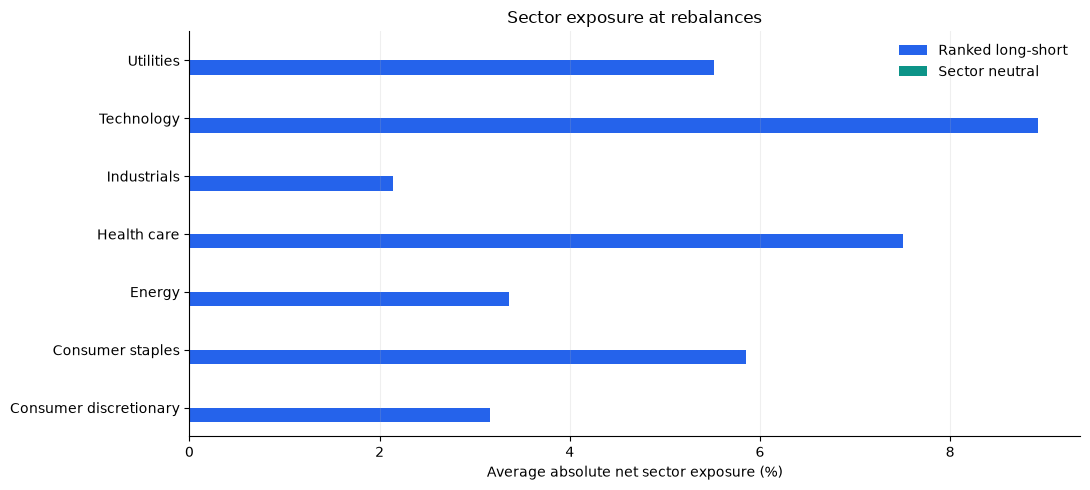

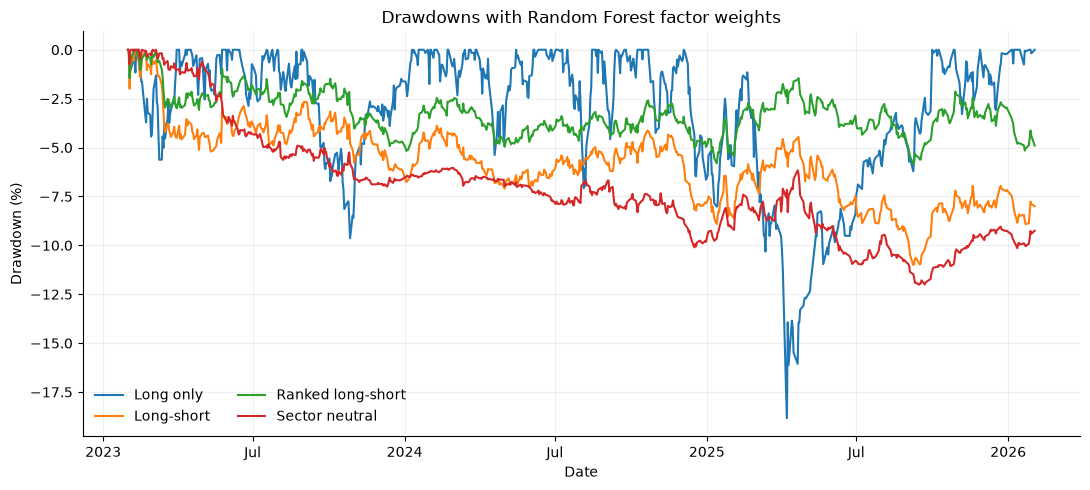

In [11]:
sector_chart = sector_exposures.loc[sector_exposures.strategy.isin(['Ranked long-short | Random Forest', 'Sector neutral | Random Forest'])].copy()
sector_chart['Absolute net exposure %'] = sector_chart.net_weight.abs() * 100
sector_chart = sector_chart.groupby(['sector', 'strategy'])['Absolute net exposure %'].mean().unstack()
sector_chart.columns = ['Ranked long-short', 'Sector neutral']
ax = sector_chart.plot.barh(figsize=(11, 5), color=['#2563eb', '#0d9488'])
ax.set(title='Sector exposure at rebalances', xlabel='Average absolute net sector exposure (%)', ylabel='')
ax.grid(axis='x', alpha=0.2)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(RESULTS / 'sector_exposure.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for mode in MODES:
    nav = portfolio_values[f'{mode} | Random Forest']
    ax.plot(nav.index, (nav / nav.cummax() - 1) * 100, label=mode)
ax.set(title='Drawdowns with Random Forest factor weights', xlabel='Date', ylabel='Drawdown (%)')
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)
locator = AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
fig.tight_layout()
fig.savefig(RESULTS / 'drawdowns.png', dpi=160)
plt.show()

We also compare the direction forecasts with the average return from each model's training months and with an Always Up prediction. These predictions describe the gross factor returns before portfolio trading and borrowing costs. The factor portfolios share stocks, so their forecasts are related observations.

In [12]:
accuracy_rows = []
for mode, group in forecasts.groupby('mode', sort=False):
    actual_up = group.actual.to_numpy() > 0
    for name, predicted in [('Random Forest', group.prediction.to_numpy()), ('Historical mean', group.training_mean.to_numpy()), ('Always Up', np.ones(len(group)))]:
        predicted_up = predicted > 0
        up_recall = predicted_up[actual_up].mean() if actual_up.any() else np.nan
        down_recall = (~predicted_up[~actual_up]).mean() if (~actual_up).any() else np.nan
        accuracy_rows.append({
            'Construction': mode, 'Forecast': name,
            'Accuracy %': 100 * (actual_up == predicted_up).mean(),
            'Balanced accuracy %': 50 * (up_recall + down_recall),
            'Down recall %': 100 * down_recall,
            'Predicted Up %': 100 * predicted_up.mean(),
            'Forecasts': len(group)
        })
accuracy = pd.DataFrame(accuracy_rows).set_index(['Construction', 'Forecast'])
accuracy.to_csv(RESULTS / 'forecast_accuracy.csv')
display(accuracy.round(2))

Accuracy %  Balanced accuracy %  \
Construction      Forecast                                           
Long only         Random Forest        64.810               46.670   
                  Historical mean      69.440               50.000   
                  Always Up            69.440               50.000   
Long-short        Random Forest        42.590               42.380   
                  Historical mean      49.070               48.560   
                  Always Up            51.850               50.000   
Ranked long-short Random Forest        42.590               42.450   
                  Historical mean      54.630               54.050   
                  Always Up            51.850               50.000   
Sector neutral    Random Forest        50.930               50.000   
                  Historical mean      57.410               51.430   
                  Always Up            41.670               50.000   

                                   Down recall %  Predicted Up %  Forecasts  
Construction      Forecast                                                   
Long only         Random Forest            0.000          95.370        108  
                  Historical mean          0.000         100.000        108  
                  Always Up                0.000         100.000        108  
Long-short        Random Forest           36.540          55.560        108  
                  Historical mean         34.620          63.890        108  
                  Always Up                0.000         100.000        108  
Ranked long-short Random Forest           38.460          53.700        108  
                  Historical mean         38.460          65.740        108  
                  Always Up                0.000         100.000        108  
Sector neutral    Random Forest           55.560          44.440        108  
                  Historical mean         87.300          13.890        108  
                  Always Up                0.000         100.000        108

In [13]:
sensitivity_rows = []
for mode in MODES[1:]:
    name = f'{mode} | Random Forest'
    for rate in [0.0, 0.03, 0.06]:
        nav, log, _ = backtest(prices, monthly_schedule, weights[name], INITIAL_VALUE, TRADING_COST, rate)
        result = performance_row(nav, log)
        sensitivity_rows.append({'Construction': mode, 'Annual borrowing assumption %': rate * 100, 'Annual return %': result['Annual return %'], 'Borrowing costs USD': result['Borrowing costs USD']})
sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(RESULTS / 'borrowing_sensitivity.csv', index=False)
display(sensitivity.pivot(index='Construction', columns='Annual borrowing assumption %', values='Annual return %').round(2))

Annual borrowing assumption %,0.000,3.000,6.000
Construction,,,
Long-short,-1.560,-2.510,-3.450
Ranked long-short,-0.640,-1.400,-2.160
Sector neutral,-2.230,-2.960,-3.690


We compared 36 monthly holding periods using the same 20 companies. Equal factor weights returned 17.12% a year after trading costs, compared with 16.85% for the four-week schedule. The monthly version had 36 rebalances compared with 40 for the four-week schedule, with trading costs of $1,157 and $1,209 respectively. The monthly long-only portfolio using Random Forest returned 15.82%. The top-five and bottom-five long-short version using Random Forest returned -2.51%, including the assumed borrowing costs. For the ranked long-short version using Random Forest, sector adjustment changed annual volatility from 4.41% to 3.12%, while annual return changed from -1.40% to -2.96%. Shared stocks were combined before trading, and the largest long-only stock weight was 20%. The sector-neutral version had zero net exposure in each sector at rebalance. Offsetting positions left it with average gross stock exposure of 49.90% at rebalances.